In [7]:
import pandas as pd

# Load the dataset
data_path = r'D:\Manoj_Honors\Merged_Data(Spatio-temporal).csv'  # Replace with your dataset path
df = pd.read_csv(data_path)

# Check for valid rows where NO2, PM2.5, and Ozone all have non-null values
valid_df = df.dropna(subset=['NO2', 'PM2.5', 'Ozone'])

# Save the valid rows to a new CSV file
output_path = r'D:\Manoj_Honors\Final/All_available(Temporal).csv'  # Replace with your desired output path
valid_df.to_csv(output_path, index=False)

# Output the number of valid samples
print(f"Total number of valid samples: {len(valid_df)}")


Total number of valid samples: 909121


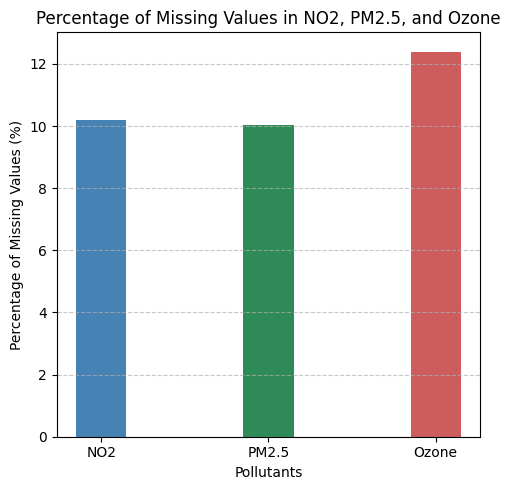

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your dataset
# Assuming your dataset is saved as 'data.csv'
data = pd.read_csv(r'D:\Manoj_Honors\Merged_Data.csv')

# Select only the relevant columns
relevant_columns = ['NO2', 'PM2.5', 'Ozone']

# Calculate the percentage of missing values for each relevant column
missing_values_percentage = (data[relevant_columns].isnull().sum() / len(data)) * 100

# Plot the bar graph
plt.figure(figsize=(5, 5))
plt.bar(missing_values_percentage.index, missing_values_percentage.values, color=['steelblue', 'seagreen', 'indianred'] ,width = 0.3)
plt.title('Percentage of Missing Values in NO2, PM2.5, and Ozone')
plt.ylabel('Percentage of Missing Values (%)')
plt.xlabel('Pollutants')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Show the plot
plt.show()


In [15]:
df = pd.read_csv(r'D:\Manoj_Honors\Merged_Data.csv')

In [17]:
no2_missing = df['NO2'].isna()

# Filter rows where NO2 is missing
no2_missing_rows = df[no2_missing]

# Count how many times either NO2_prev_day or NO2_prev_week is missing in these rows
prev_data_missing_count = (no2_missing_rows['NO2_prev_day'].isna() | no2_missing_rows['NO2_prev_week'].isna()).sum()

print("Rows where NO2 is missing:")
print(no2_missing_rows)

print(f"Count of rows where either NO2_prev_day or NO2_prev_week is missing when NO2 is missing: {prev_data_missing_count}")

Rows where NO2 is missing:
                        Time  Station_ID  NO2  PM2.5  Ozone        Lat  \
4        2023-01-01 02:00:00           0  NaN  103.0   2.90  28.815329   
43       2023-01-01 21:30:00           0  NaN    NaN    NaN  28.815329   
44       2023-01-01 22:00:00           0  NaN    NaN    NaN  28.815329   
45       2023-01-01 22:30:00           0  NaN    NaN    NaN  28.815329   
46       2023-01-01 23:00:00           0  NaN    NaN    NaN  28.815329   
...                      ...         ...  ...    ...    ...        ...   
1107718  2024-06-29 07:00:00          39  NaN    NaN    NaN  28.651478   
1107719  2024-06-29 07:30:00          39  NaN    NaN    NaN  28.651478   
1107720  2024-06-29 08:00:00          39  NaN    NaN    NaN  28.651478   
1107728  2024-06-29 12:00:00          39  NaN    NaN   3.26  28.651478   
1107729  2024-06-29 12:30:00          39  NaN    NaN   6.03  28.651478   

               Lon  NO2_prev_day  PM2.5_prev_day  Ozone_prev_day  \
4        77.1530

In [4]:
relevant_columns = ['NO2','NO2_prev_day','NO2_prev_week']
data[relevant_columns].isnull().sum() 

NO2                113000
PM2.5              111193
Ozone              137327
NO2_prev_day       114653
PM2.5_prev_day     112731
Ozone_prev_day     138856
PM2.5_prev_week    122349
Ozone_prev_week    148414
NO2_prev_week      124935
dtype: int64

In [2]:
import pandas as pd

# Load the dataset
data_path = r'D:\Manoj_Honors\Merged_Data(Spatio-temporal).csv'  # Replace with your dataset path
df = pd.read_csv(data_path)

# Define the conditions for each scenario
no2_ava = df[df['NO2'].notna() & df['PM2.5'].isna() & df['Ozone'].isna()]
pm25_ava = df[df['PM2.5'].notna() & df['NO2'].isna() & df['Ozone'].isna()]
ozone_ava = df[df['Ozone'].notna() & df['PM2.5'].isna() & df['NO2'].isna()]

# Save each condition to a separate CSV file
output_base_path = r'D:\Manoj_Honors\Final/'  # Base path for outputs

no2_ava.to_csv(f'{output_base_path}no2_ava.csv', index=False)
pm25_ava.to_csv(f'{output_base_path}pm25_ava.csv', index=False)
ozone_ava.to_csv(f'{output_base_path}ozone_ava.csv', index=False)

# Output the number of valid samples for each condition
print(f"PM2.5 and Ozone not available but NO2 ava: {len(no2_ava)}")
print(f"Ozone and NO2 not available but PM2.5 ava: {len(pm25_ava)}")
print(f"PM2.5 and NO2 not available but Ozone ava: {len(ozone_ava)}")

PM2.5 and Ozone not available but NO2 ava: 4131
Ozone and NO2 not available but PM2.5 ava: 3248
PM2.5 and NO2 not available but Ozone ava: 2150


In [3]:
import pandas as pd

# Load the dataset
data_path = r'D:\Manoj_Honors\Merged_Data(Spatio-temporal).csv'  # Replace with your dataset path
df = pd.read_csv(data_path)

# Define the conditions for each scenario
no2_missing = df[df['NO2'].isna() & df['PM2.5'].notna() & df['Ozone'].notna()]
pm25_missing = df[df['PM2.5'].isna() & df['NO2'].notna() & df['Ozone'].notna()]
ozone_missing = df[df['Ozone'].isna() & df['PM2.5'].notna() & df['NO2'].notna()]

# Save each condition to a separate CSV file
output_base_path = r'D:\Manoj_Honors\Final/'  # Base path for outputs

no2_missing.to_csv(f'{output_base_path}no2_missing.csv', index=False)
pm25_missing.to_csv(f'{output_base_path}pm25_missing.csv', index=False)
ozone_missing.to_csv(f'{output_base_path}ozone_missing.csv', index=False)

# Output the number of valid samples for each condition
print(f"PM2.5 and Ozone available but NO2 not : {len(no2_ava)}")
print(f"Ozone and NO2  available but PM2.5 not: {len(pm25_ava)}")
print(f"PM2.5 and NO2  available but Ozone not : {len(ozone_ava)}")

PM2.5 and Ozone available but NO2 not : 4131
Ozone and NO2  available but PM2.5 not: 3248
PM2.5 and NO2  available but Ozone not : 2150


In [4]:
data_path = r'D:\Manoj_Honors\Merged_Data(Spatio-temporal).csv'   # Replace with your dataset path
df = pd.read_csv(data_path)

# Define the conditions for each scenario
all_not_ava = df[df['NO2'].isna() & df['PM2.5'].isna() & df['Ozone'].isna()]

# Save each condition to a separate CSV file
output_base_path = r'D:\Manoj_Honors\Final/'  # Base path for outputs

all_not_ava.to_csv(f'{output_base_path}all_not_ava.csv', index=False)


# Output the number of valid samples for each condition
print(f"all_not_ava: {len(all_not_ava)}")

all_not_ava: 76656


In [19]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_score

In [3]:
df = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')
df.isna().sum()

<>:1: SyntaxWarning: invalid escape sequence '\M'
<>:1: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Faculty\AppData\Local\Temp\ipykernel_23488\1757854529.py:1: SyntaxWarning: invalid escape sequence '\M'
  df = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')


Time                     0
Station_ID               0
NO2                      0
PM2.5                    0
Ozone                    0
Lat                      0
Lon                      0
NO2_prev_day         30518
PM2.5_prev_day       33726
Ozone_prev_day       34954
NO2_prev_week        55236
PM2.5_prev_week      56495
Ozone_prev_week      59587
Spatial_Avg_PM2.5     1372
Spatial_Avg_Ozone     2558
Spatial_Avg_NO2       2199
dtype: int64

Uni-Variate

In [20]:
# Load the dataset
all_available = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')

all_available = all_available.dropna()
print(len(all_available))

X = all_available[['Time', 'Lat','Lon','PM2.5_prev_day','PM2.5_prev_week','Spatial_Avg_PM2.5']]
y = all_available['PM2.5']

# Convert 'Time' to numeric if it's in datetime format
X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9  # Convert to seconds


# Initialize the Random Forest model
rf = RandomForestRegressor(n_estimators=100, random_state=12)

# Initialize KFold for cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=12)

# Prepare lists to store scores for each fold
mse_scores = []
mae_scores = []
r2_scores = []
mape_scores = []
nrmse_scores = []

# Perform cross-validation
for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Fit the model on the training data
    rf.fit(X_train, y_train)

    # Make predictions on the test data
    y_pred = rf.predict(X_test)

    # Calculate evaluation metrics
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    nrmse = np.sqrt(mse) / (y_test.max() - y_test.min())

    mse_scores.append(mse)
    mae_scores.append(mae)
    r2_scores.append(r2)
    mape_scores.append(mape)
    nrmse_scores.append(nrmse)

# Calculate mean and standard deviation for each metric
mean_mse = np.mean(mse_scores)
std_mse = np.std(mse_scores)
mean_mae = np.mean(mae_scores)
std_mae = np.std(mae_scores)
mean_r2 = np.mean(r2_scores)
std_r2 = np.std(r2_scores)
mean_mape = np.mean(mape_scores)
std_mape = np.std(mape_scores)
mean_nrmse = np.mean(nrmse_scores)
std_nrmse = np.std(nrmse_scores)

# Print evaluation metrics
print(f"Mean Squared Error: {round(mean_mse, 2)} ± {round(std_mse, 2)}")
print(f"Mean Absolute Error: {round(mean_mae, 2)} ± {round(std_mae, 2)}")
print(f"R^2 Score: {round(mean_r2, 2)} ± {round(std_r2, 2)}")
print(f"Mean Absolute Percentage Error: {round(mean_mape, 2)}% ± {round(std_mape, 2)}%")
print(f"Normalized RMSE: {round(mean_nrmse, 4)} ± {round(std_nrmse, 4)}")

import pickle

with open('random_forest_model_PM2.5(STC).pkl', 'wb') as model_file:
 pickle.dump(rf, model_file)


<>:2: SyntaxWarning: invalid escape sequence '\M'
<>:2: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Faculty\AppData\Local\Temp\ipykernel_1096\1904027898.py:2: SyntaxWarning: invalid escape sequence '\M'
  all_available = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')


764702


C:\Users\Faculty\AppData\Local\Temp\ipykernel_1096\1904027898.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9  # Convert to seconds


Mean Squared Error: 765.6 ± 9.46
Mean Absolute Error: 15.86 ± 0.04
R^2 Score: 0.9 ± 0.0
Mean Absolute Percentage Error: 47.89% ± 2.89%
Normalized RMSE: 0.0278 ± 0.0002


In [6]:
# Load the dataset
all_available = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')

all_available = all_available.dropna()
print(len(all_available))

X = all_available[['Time', 'Lat','Lon','PM2.5_prev_day','PM2.5_prev_week','Spatial_Avg_PM2.5','NO2','Ozone']]
y = all_available['PM2.5']

# Convert 'Time' to numeric if it's in datetime format
X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9  # Convert to seconds


# Initialize the Random Forest model
rf = RandomForestRegressor(n_estimators=100, random_state=12)

# Initialize KFold for cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=12)

# Prepare lists to store scores for each fold
mse_scores = []
mae_scores = []
r2_scores = []
mape_scores = []
nrmse_scores = []

# Perform cross-validation
for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Fit the model on the training data
    rf.fit(X_train, y_train)

    # Make predictions on the test data
    y_pred = rf.predict(X_test)

    # Calculate evaluation metrics
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    nrmse = np.sqrt(mse) / (y_test.max() - y_test.min())

    mse_scores.append(mse)
    mae_scores.append(mae)
    r2_scores.append(r2)
    mape_scores.append(mape)
    nrmse_scores.append(nrmse)

# Calculate mean and standard deviation for each metric
mean_mse = np.mean(mse_scores)
std_mse = np.std(mse_scores)
mean_mae = np.mean(mae_scores)
std_mae = np.std(mae_scores)
mean_r2 = np.mean(r2_scores)
std_r2 = np.std(r2_scores)
mean_mape = np.mean(mape_scores)
std_mape = np.std(mape_scores)
mean_nrmse = np.mean(nrmse_scores)
std_nrmse = np.std(nrmse_scores)

# Print evaluation metrics
print(f"Mean Squared Error: {round(mean_mse, 2)} ± {round(std_mse, 2)}")
print(f"Mean Absolute Error: {round(mean_mae, 2)} ± {round(std_mae, 2)}")
print(f"R^2 Score: {round(mean_r2, 2)} ± {round(std_r2, 2)}")
print(f"Mean Absolute Percentage Error: {round(mean_mape, 2)}% ± {round(std_mape, 2)}%")
print(f"Normalized RMSE: {round(mean_nrmse, 4)} ± {round(std_nrmse, 4)}")

import pickle

with open('random_forest_model_PM2.5.pkl', 'wb') as model_file:
    pickle.dump(rf, model_file)


<>:2: SyntaxWarning: invalid escape sequence '\M'
<>:2: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Faculty\AppData\Local\Temp\ipykernel_23488\4160941345.py:2: SyntaxWarning: invalid escape sequence '\M'
  all_available = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')


764702


C:\Users\Faculty\AppData\Local\Temp\ipykernel_23488\4160941345.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9  # Convert to seconds


Mean Squared Error: 782.19 ± 10.68
Mean Absolute Error: 16.09 ± 0.01
R^2 Score: 0.9 ± 0.0
Mean Absolute Percentage Error: 47.57% ± 2.84%
Normalized RMSE: 0.0281 ± 0.0003


In [39]:
# Load the dataset
all_available = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')

all_available = all_available.dropna()
print(len(all_available))

X = all_available[['Time', 'Lat','Lon','NO2_prev_day','NO2_prev_week','Spatial_Avg_NO2','NO2','Ozone_prev_day','Ozone_prev_week','Spatial_Avg_Ozone','Ozone']]
y = all_available['PM2.5']

# Convert 'Time' to numeric if it's in datetime format
X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9  # Convert to seconds


# Initialize the Random Forest model
rf = RandomForestRegressor(n_estimators=100, random_state=12)

# Initialize KFold for cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=12)

# Prepare lists to store scores for each fold
mse_scores = []
mae_scores = []
r2_scores = []
mape_scores = []
nrmse_scores = []

# Perform cross-validation
for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Fit the model on the training data
    rf.fit(X_train, y_train)

    # Make predictions on the test data
    y_pred = rf.predict(X_test)

    # Calculate evaluation metrics
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    nrmse = np.sqrt(mse) / (y_test.max() - y_test.min())

    mse_scores.append(mse)
    mae_scores.append(mae)
    r2_scores.append(r2)
    mape_scores.append(mape)
    nrmse_scores.append(nrmse)

# Calculate mean and standard deviation for each metric
mean_mse = np.mean(mse_scores)
std_mse = np.std(mse_scores)
mean_mae = np.mean(mae_scores)
std_mae = np.std(mae_scores)
mean_r2 = np.mean(r2_scores)
std_r2 = np.std(r2_scores)
mean_mape = np.mean(mape_scores)
std_mape = np.std(mape_scores)
mean_nrmse = np.mean(nrmse_scores)
std_nrmse = np.std(nrmse_scores)

# Print evaluation metrics
print(f"Mean Squared Error: {round(mean_mse, 2)} ± {round(std_mse, 2)}")
print(f"Mean Absolute Error: {round(mean_mae, 2)} ± {round(std_mae, 2)}")
print(f"R^2 Score: {round(mean_r2, 2)} ± {round(std_r2, 2)}")
print(f"Mean Absolute Percentage Error: {round(mean_mape, 2)}% ± {round(std_mape, 2)}%")
print(f"Normalized RMSE: {round(mean_nrmse, 4)} ± {round(std_nrmse, 4)}")

import pickle

with open('random_forest_model_PM2.5(CC).pkl', 'wb') as model_file:
    pickle.dump(rf, model_file)


<>:2: SyntaxWarning: invalid escape sequence '\M'
<>:2: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Faculty\AppData\Local\Temp\ipykernel_23488\3324422214.py:2: SyntaxWarning: invalid escape sequence '\M'
  all_available = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')


764702


C:\Users\Faculty\AppData\Local\Temp\ipykernel_23488\3324422214.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9  # Convert to seconds


Mean Squared Error: 814.1 ± 8.11
Mean Absolute Error: 16.66 ± 0.03
R^2 Score: 0.9 ± 0.0
Mean Absolute Percentage Error: 48.38% ± 2.58%
Normalized RMSE: 0.0287 ± 0.0003


In [13]:
# Load the dataset
all_available = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')

all_available = all_available.dropna()
print(len(all_available))

X = all_available[['Time', 'Lat','Lon','NO2_prev_day','NO2_prev_week','Spatial_Avg_NO2','NO2','Ozone','Ozone_prev_day','Ozone_prev_week','Spatial_Avg_Ozone','PM2.5_prev_day','PM2.5_prev_week','Spatial_Avg_PM2.5']]
y = all_available['PM2.5']

# Convert 'Time' to numeric if it's in datetime format
X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9  # Convert to seconds


# Initialize the Random Forest model
rf = RandomForestRegressor(n_estimators=100, random_state=12)

# Initialize KFold for cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=12)

# Prepare lists to store scores for each fold
mse_scores = []
mae_scores = []
r2_scores = []
mape_scores = []
nrmse_scores = []

# Perform cross-validation
for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Fit the model on the training data
    rf.fit(X_train, y_train)

    # Make predictions on the test data
    y_pred = rf.predict(X_test)

    # Calculate evaluation metrics
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    nrmse = np.sqrt(mse) / (y_test.max() - y_test.min())

    mse_scores.append(mse)
    mae_scores.append(mae)
    r2_scores.append(r2)
    mape_scores.append(mape)
    nrmse_scores.append(nrmse)

# Calculate mean and standard deviation for each metric
mean_mse = np.mean(mse_scores)
std_mse = np.std(mse_scores)
mean_mae = np.mean(mae_scores)
std_mae = np.std(mae_scores)
mean_r2 = np.mean(r2_scores)
std_r2 = np.std(r2_scores)
mean_mape = np.mean(mape_scores)
std_mape = np.std(mape_scores)
mean_nrmse = np.mean(nrmse_scores)
std_nrmse = np.std(nrmse_scores)

# Print evaluation metrics
print(f"Mean Squared Error: {round(mean_mse, 2)} ± {round(std_mse, 2)}")
print(f"Mean Absolute Error: {round(mean_mae, 2)} ± {round(std_mae, 2)}")
print(f"R^2 Score: {round(mean_r2, 2)} ± {round(std_r2, 2)}")
print(f"Mean Absolute Percentage Error: {round(mean_mape, 2)}% ± {round(std_mape, 2)}%")
print(f"Normalized RMSE: {round(mean_nrmse, 4)} ± {round(std_nrmse, 4)}")

# import pickle

# with open('random_forest_model_PM2.5.pkl', 'wb') as model_file:
#     pickle.dump(rf, model_file)


<>:2: SyntaxWarning: invalid escape sequence '\M'
<>:2: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Faculty\AppData\Local\Temp\ipykernel_15464\1275233522.py:2: SyntaxWarning: invalid escape sequence '\M'
  all_available = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')


764702


C:\Users\Faculty\AppData\Local\Temp\ipykernel_15464\1275233522.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9  # Convert to seconds


Mean Squared Error: 786.03 ± 12.54
Mean Absolute Error: 16.19 ± 0.01
R^2 Score: 0.9 ± 0.0
Mean Absolute Percentage Error: 47.75% ± 2.83%
Normalized RMSE: 0.0282 ± 0.0003


In [14]:
# Load the dataset
all_available = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')

all_available = all_available.dropna()
print(len(all_available))

X = all_available[['Time', 'Lat','Lon','NO2_prev_day','NO2_prev_week','NO2','Ozone','Ozone_prev_day','Ozone_prev_week','PM2.5_prev_day','PM2.5_prev_week']]
y = all_available['PM2.5']

# Convert 'Time' to numeric if it's in datetime format
X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9  # Convert to seconds


# Initialize the Random Forest model
rf = RandomForestRegressor(n_estimators=100, random_state=12)

# Initialize KFold for cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=12)

# Prepare lists to store scores for each fold
mse_scores = []
mae_scores = []
r2_scores = []
mape_scores = []
nrmse_scores = []

# Perform cross-validation
for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Fit the model on the training data
    rf.fit(X_train, y_train)

    # Make predictions on the test data
    y_pred = rf.predict(X_test)

    # Calculate evaluation metrics
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    nrmse = np.sqrt(mse) / (y_test.max() - y_test.min())

    mse_scores.append(mse)
    mae_scores.append(mae)
    r2_scores.append(r2)
    mape_scores.append(mape)
    nrmse_scores.append(nrmse)

# Calculate mean and standard deviation for each metric
mean_mse = np.mean(mse_scores)
std_mse = np.std(mse_scores)
mean_mae = np.mean(mae_scores)
std_mae = np.std(mae_scores)
mean_r2 = np.mean(r2_scores)
std_r2 = np.std(r2_scores)
mean_mape = np.mean(mape_scores)
std_mape = np.std(mape_scores)
mean_nrmse = np.mean(nrmse_scores)
std_nrmse = np.std(nrmse_scores)

# Print evaluation metrics
print(f"Mean Squared Error: {round(mean_mse, 2)} ± {round(std_mse, 2)}")
print(f"Mean Absolute Error: {round(mean_mae, 2)} ± {round(std_mae, 2)}")
print(f"R^2 Score: {round(mean_r2, 2)} ± {round(std_r2, 2)}")
print(f"Mean Absolute Percentage Error: {round(mean_mape, 2)}% ± {round(std_mape, 2)}%")
print(f"Normalized RMSE: {round(mean_nrmse, 4)} ± {round(std_nrmse, 4)}")

# import pickle

# with open('random_forest_model_PM2.5.pkl', 'wb') as model_file:
#     pickle.dump(rf, model_file)


<>:2: SyntaxWarning: invalid escape sequence '\M'
<>:2: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Faculty\AppData\Local\Temp\ipykernel_15464\1384019675.py:2: SyntaxWarning: invalid escape sequence '\M'
  all_available = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')


764702


C:\Users\Faculty\AppData\Local\Temp\ipykernel_15464\1384019675.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9  # Convert to seconds


Mean Squared Error: 802.96 ± 8.3
Mean Absolute Error: 16.71 ± 0.02
R^2 Score: 0.9 ± 0.0
Mean Absolute Percentage Error: 52.68% ± 3.47%
Normalized RMSE: 0.0285 ± 0.0002


In [10]:
# Load the dataset
all_available = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')

all_available = all_available.dropna()
print(len(all_available))

X = all_available[['Time', 'Lat','Lon','PM2.5_prev_day','PM2.5_prev_week','Spatial_Avg_PM2.5']]
y = all_available['PM2.5']

# Convert 'Time' to numeric if it's in datetime format
X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9  # Convert to seconds

# Initialize the XGBoost model
xg_reg = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1)

# Initialize KFold for cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=12)

# Prepare lists to store scores for each fold
mse_scores = []
mae_scores = []
r2_scores = []
mape_scores = []
nrmse_scores = []

# Perform cross-validation
for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Fit the model on the training data
    xg_reg.fit(X_train, y_train)

    # Make predictions on the test data
    y_pred = xg_reg.predict(X_test)

    # Calculate evaluation metrics
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100  # MAPE calculation
    nrmse = np.sqrt(mse) / (y_test.max() - y_test.min()) * 100  # NRMSE calculation

    # Append scores for each fold
    mse_scores.append(mse)
    mae_scores.append(mae)
    r2_scores.append(r2)
    mape_scores.append(mape)
    nrmse_scores.append(nrmse)

# Calculate mean and standard deviation for each metric
mean_mse = np.mean(mse_scores)
std_mse = np.std(mse_scores)
mean_mae = np.mean(mae_scores)
std_mae = np.std(mae_scores)
mean_r2 = np.mean(r2_scores)
std_r2 = np.std(r2_scores)
mean_mape = np.mean(mape_scores)
std_mape = np.std(mape_scores)
mean_nrmse = np.mean(nrmse_scores)
std_nrmse = np.std(nrmse_scores)

# Print evaluation metrics
print(f"Mean Squared Error: {round(mean_mse, 2)} ± {round(std_mse, 2)}")
print(f"Mean Absolute Error: {round(mean_mae, 2)} ± {round(std_mae, 2)}")
print(f"R^2 Score: {round(mean_r2, 2)} ± {round(std_r2, 2)}")
print(f"Mean Absolute Percentage Error: {round(mean_mape, 2)} ± {round(std_mape, 2)}%")
print(f"Normalized RMSE: {round(mean_nrmse, 2)} ± {round(std_nrmse, 2)}%")


<>:2: SyntaxWarning: invalid escape sequence '\M'
<>:2: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Faculty\AppData\Local\Temp\ipykernel_15464\3327464431.py:2: SyntaxWarning: invalid escape sequence '\M'
  all_available = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')


764702


C:\Users\Faculty\AppData\Local\Temp\ipykernel_15464\3327464431.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9  # Convert to seconds


Mean Squared Error: 1205.64 ± 11.23
Mean Absolute Error: 21.23 ± 0.07
R^2 Score: 0.85 ± 0.0
Mean Absolute Percentage Error: 57.78 ± 2.82%
Normalized RMSE: 3.49 ± 0.03%


In [11]:
# Load the dataset
all_available = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')

all_available = all_available.dropna()
print(len(all_available))

X = all_available[['Time', 'Lat','Lon','PM2.5_prev_day','PM2.5_prev_week','Spatial_Avg_PM2.5','NO2','Ozone']]
y = all_available['PM2.5']

# Convert 'Time' to numeric if it's in datetime format
X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9  # Convert to seconds

# Initialize the XGBoost model
xg_reg = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1)

# Initialize KFold for cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=12)

# Prepare lists to store scores for each fold
mse_scores = []
mae_scores = []
r2_scores = []
mape_scores = []
nrmse_scores = []

# Perform cross-validation
for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Fit the model on the training data
    xg_reg.fit(X_train, y_train)

    # Make predictions on the test data
    y_pred = xg_reg.predict(X_test)

    # Calculate evaluation metrics
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100  # MAPE calculation
    nrmse = np.sqrt(mse) / (y_test.max() - y_test.min()) * 100  # NRMSE calculation

    # Append scores for each fold
    mse_scores.append(mse)
    mae_scores.append(mae)
    r2_scores.append(r2)
    mape_scores.append(mape)
    nrmse_scores.append(nrmse)

# Calculate mean and standard deviation for each metric
mean_mse = np.mean(mse_scores)
std_mse = np.std(mse_scores)
mean_mae = np.mean(mae_scores)
std_mae = np.std(mae_scores)
mean_r2 = np.mean(r2_scores)
std_r2 = np.std(r2_scores)
mean_mape = np.mean(mape_scores)
std_mape = np.std(mape_scores)
mean_nrmse = np.mean(nrmse_scores)
std_nrmse = np.std(nrmse_scores)

# Print evaluation metrics
print(f"Mean Squared Error: {round(mean_mse, 2)} ± {round(std_mse, 2)}")
print(f"Mean Absolute Error: {round(mean_mae, 2)} ± {round(std_mae, 2)}")
print(f"R^2 Score: {round(mean_r2, 2)} ± {round(std_r2, 2)}")
print(f"Mean Absolute Percentage Error: {round(mean_mape, 2)} ± {round(std_mape, 2)}%")
print(f"Normalized RMSE: {round(mean_nrmse, 2)} ± {round(std_nrmse, 2)}%")


<>:2: SyntaxWarning: invalid escape sequence '\M'
<>:2: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Faculty\AppData\Local\Temp\ipykernel_15464\3408359911.py:2: SyntaxWarning: invalid escape sequence '\M'
  all_available = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')


764702


C:\Users\Faculty\AppData\Local\Temp\ipykernel_15464\3408359911.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9  # Convert to seconds


Mean Squared Error: 1185.89 ± 14.34
Mean Absolute Error: 21.05 ± 0.03
R^2 Score: 0.85 ± 0.0
Mean Absolute Percentage Error: 57.19 ± 2.68%
Normalized RMSE: 3.46 ± 0.04%


In [15]:
# Load the dataset
all_available = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')

all_available = all_available.dropna()
print(len(all_available))

X = all_available[['Time', 'Lat','Lon','NO2_prev_day','NO2_prev_week','Spatial_Avg_NO2','NO2','Ozone','Ozone_prev_day','Ozone_prev_week','Spatial_Avg_Ozone']]
y = all_available['PM2.5']

# Convert 'Time' to numeric if it's in datetime format
X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9  # Convert to seconds

# Initialize the XGBoost model
xg_reg = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1)

# Initialize KFold for cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=12)

# Prepare lists to store scores for each fold
mse_scores = []
mae_scores = []
r2_scores = []
mape_scores = []
nrmse_scores = []

# Perform cross-validation
for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Fit the model on the training data
    xg_reg.fit(X_train, y_train)

    # Make predictions on the test data
    y_pred = xg_reg.predict(X_test)

    # Calculate evaluation metrics
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100  # MAPE calculation
    nrmse = np.sqrt(mse) / (y_test.max() - y_test.min()) * 100  # NRMSE calculation

    # Append scores for each fold
    mse_scores.append(mse)
    mae_scores.append(mae)
    r2_scores.append(r2)
    mape_scores.append(mape)
    nrmse_scores.append(nrmse)

# Calculate mean and standard deviation for each metric
mean_mse = np.mean(mse_scores)
std_mse = np.std(mse_scores)
mean_mae = np.mean(mae_scores)
std_mae = np.std(mae_scores)
mean_r2 = np.mean(r2_scores)
std_r2 = np.std(r2_scores)
mean_mape = np.mean(mape_scores)
std_mape = np.std(mape_scores)
mean_nrmse = np.mean(nrmse_scores)
std_nrmse = np.std(nrmse_scores)

# Print evaluation metrics
print(f"Mean Squared Error: {round(mean_mse, 2)} ± {round(std_mse, 2)}")
print(f"Mean Absolute Error: {round(mean_mae, 2)} ± {round(std_mae, 2)}")
print(f"R^2 Score: {round(mean_r2, 2)} ± {round(std_r2, 2)}")
print(f"Mean Absolute Percentage Error: {round(mean_mape, 2)} ± {round(std_mape, 2)}%")
print(f"Normalized RMSE: {round(mean_nrmse, 2)} ± {round(std_nrmse, 2)}%")


<>:2: SyntaxWarning: invalid escape sequence '\M'
<>:2: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Faculty\AppData\Local\Temp\ipykernel_15464\2141016452.py:2: SyntaxWarning: invalid escape sequence '\M'
  all_available = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')


764702


C:\Users\Faculty\AppData\Local\Temp\ipykernel_15464\2141016452.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9  # Convert to seconds


Mean Squared Error: 2395.39 ± 22.14
Mean Absolute Error: 31.93 ± 0.05
R^2 Score: 0.69 ± 0.0
Mean Absolute Percentage Error: 86.48 ± 3.48%
Normalized RMSE: 4.92 ± 0.03%


In [18]:
# Load the dataset
all_available = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')

all_available = all_available.dropna()
print(len(all_available))

X = all_available[['Time', 'Lat','Lon','NO2_prev_day','NO2_prev_week','Spatial_Avg_NO2','NO2','Ozone','Ozone_prev_day','Ozone_prev_week','Spatial_Avg_Ozone','PM2.5_prev_day','PM2.5_prev_week','Spatial_Avg_PM2.5']]
y = all_available['PM2.5']

# Convert 'Time' to numeric if it's in datetime format
X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9  # Convert to seconds

# Initialize the XGBoost model
xg_reg = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1)

# Initialize KFold for cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=12)

# Prepare lists to store scores for each fold
mse_scores = []
mae_scores = []
r2_scores = []
mape_scores = []
nrmse_scores = []

# Perform cross-validation
for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Fit the model on the training data
    xg_reg.fit(X_train, y_train)

    # Make predictions on the test data
    y_pred = xg_reg.predict(X_test)

    # Calculate evaluation metrics
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100  # MAPE calculation
    nrmse = np.sqrt(mse) / (y_test.max() - y_test.min()) * 100  # NRMSE calculation

    # Append scores for each fold
    mse_scores.append(mse)
    mae_scores.append(mae)
    r2_scores.append(r2)
    mape_scores.append(mape)
    nrmse_scores.append(nrmse)

# Calculate mean and standard deviation for each metric
mean_mse = np.mean(mse_scores)
std_mse = np.std(mse_scores)
mean_mae = np.mean(mae_scores)
std_mae = np.std(mae_scores)
mean_r2 = np.mean(r2_scores)
std_r2 = np.std(r2_scores)
mean_mape = np.mean(mape_scores)
std_mape = np.std(mape_scores)
mean_nrmse = np.mean(nrmse_scores)
std_nrmse = np.std(nrmse_scores)

# Print evaluation metrics
print(f"Mean Squared Error: {round(mean_mse, 2)} ± {round(std_mse, 2)}")
print(f"Mean Absolute Error: {round(mean_mae, 2)} ± {round(std_mae, 2)}")
print(f"R^2 Score: {round(mean_r2, 2)} ± {round(std_r2, 2)}")
print(f"Mean Absolute Percentage Error: {round(mean_mape, 2)} ± {round(std_mape, 2)}%")
print(f"Normalized RMSE: {round(mean_nrmse, 2)} ± {round(std_nrmse, 2)}%")


<>:2: SyntaxWarning: invalid escape sequence '\M'
<>:2: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Faculty\AppData\Local\Temp\ipykernel_15464\2033740053.py:2: SyntaxWarning: invalid escape sequence '\M'
  all_available = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')


764702


C:\Users\Faculty\AppData\Local\Temp\ipykernel_15464\2033740053.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9  # Convert to seconds


Mean Squared Error: 1184.73 ± 12.45
Mean Absolute Error: 21.04 ± 0.05
R^2 Score: 0.85 ± 0.0
Mean Absolute Percentage Error: 57.27 ± 2.93%
Normalized RMSE: 3.46 ± 0.04%


In [20]:
# Load the dataset
all_available = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')

all_available = all_available.dropna()
print(len(all_available))

X = all_available[['Time', 'Lat','Lon','NO2_prev_day','NO2_prev_week','NO2','Ozone','Ozone_prev_day','Ozone_prev_week','PM2.5_prev_day','PM2.5_prev_week']]
y = all_available['PM2.5']

# Convert 'Time' to numeric if it's in datetime format
X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9  # Convert to seconds

# Initialize the XGBoost model
xg_reg = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1)

# Initialize KFold for cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=12)

# Prepare lists to store scores for each fold
mse_scores = []
mae_scores = []
r2_scores = []
mape_scores = []
nrmse_scores = []

# Perform cross-validation
for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Fit the model on the training data
    xg_reg.fit(X_train, y_train)

    # Make predictions on the test data
    y_pred = xg_reg.predict(X_test)

    # Calculate evaluation metrics
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100  # MAPE calculation
    nrmse = np.sqrt(mse) / (y_test.max() - y_test.min()) * 100  # NRMSE calculation

    # Append scores for each fold
    mse_scores.append(mse)
    mae_scores.append(mae)
    r2_scores.append(r2)
    mape_scores.append(mape)
    nrmse_scores.append(nrmse)

# Calculate mean and standard deviation for each metric
mean_mse = np.mean(mse_scores)
std_mse = np.std(mse_scores)
mean_mae = np.mean(mae_scores)
std_mae = np.std(mae_scores)
mean_r2 = np.mean(r2_scores)
std_r2 = np.std(r2_scores)
mean_mape = np.mean(mape_scores)
std_mape = np.std(mape_scores)
mean_nrmse = np.mean(nrmse_scores)
std_nrmse = np.std(nrmse_scores)

# Print evaluation metrics
print(f"Mean Squared Error: {round(mean_mse, 2)} ± {round(std_mse, 2)}")
print(f"Mean Absolute Error: {round(mean_mae, 2)} ± {round(std_mae, 2)}")
print(f"R^2 Score: {round(mean_r2, 2)} ± {round(std_r2, 2)}")
print(f"Mean Absolute Percentage Error: {round(mean_mape, 2)} ± {round(std_mape, 2)}%")
print(f"Normalized RMSE: {round(mean_nrmse, 2)} ± {round(std_nrmse, 2)}%")


<>:2: SyntaxWarning: invalid escape sequence '\M'
<>:2: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Faculty\AppData\Local\Temp\ipykernel_15464\3310652405.py:2: SyntaxWarning: invalid escape sequence '\M'
  all_available = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')


764702


C:\Users\Faculty\AppData\Local\Temp\ipykernel_15464\3310652405.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9  # Convert to seconds


Mean Squared Error: 2143.87 ± 17.97
Mean Absolute Error: 29.94 ± 0.03
R^2 Score: 0.73 ± 0.0
Mean Absolute Percentage Error: 82.23 ± 3.42%
Normalized RMSE: 4.66 ± 0.04%


In [25]:
# Load the dataset
all_available = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')

all_available = all_available.dropna()
print(len(all_available))

X = all_available[[ 'Time', 'Lat','Lon','PM2.5_prev_day','PM2.5_prev_week','Spatial_Avg_PM2.5','NO2','Ozone']]
y = all_available['PM2.5']

# Convert 'Time' to numeric if it's in datetime format
X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9  # Convert to seconds

# Initialize the Multiple Linear Regression model
mlr = LinearRegression()

# Initialize KFold for cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=12)

# Prepare lists to store scores for each fold
mse_scores = []
mae_scores = []
r2_scores = []
mape_scores = []
nrmse_scores = []

# Perform cross-validation
for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Fit the model on the training data
    mlr.fit(X_train, y_train)

    # Make predictions on the test data
    y_pred = mlr.predict(X_test)

    # Calculate evaluation metrics
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100  # MAPE calculation
    nrmse = np.sqrt(mse) / (y_test.max() - y_test.min()) * 100  # NRMSE calculation


    # Append metrics to lists
    mse_scores.append(mse)
    mae_scores.append(mae)
    r2_scores.append(r2)
    mape_scores.append(mape )
    nrmse_scores.append(nrmse)

# Calculate mean and standard deviation for each metric
mean_mse = np.mean(mse_scores)
std_mse = np.std(mse_scores)
mean_mae = np.mean(mae_scores)
std_mae = np.std(mae_scores)
mean_r2 = np.mean(r2_scores)
std_r2 = np.std(r2_scores)
mean_mape = np.mean(mape_scores)
std_mape = np.std(mape_scores)
mean_nrmse = np.mean(nrmse_scores)
std_nrmse = np.std(nrmse_scores)

# Print evaluation metrics
print(f"Mean Squared Error: {round(mean_mse, 2)} ± {round(std_mse, 2)}")
print(f"Mean Absolute Error: {round(mean_mae, 2)} ± {round(std_mae, 2)}")
print(f"R^2 Score: {round(mean_r2, 2)} ± {round(std_r2, 2)}")
print(f"Mean Absolute Percentage Error: {round(mean_mape, 2)} ± {round(std_mape, 2)}%")
print(f"Normalized RMSE: {round(mean_nrmse, 2)} ± {round(std_nrmse, 2)}%")


<>:2: SyntaxWarning: invalid escape sequence '\M'
<>:2: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Faculty\AppData\Local\Temp\ipykernel_15464\1090217061.py:2: SyntaxWarning: invalid escape sequence '\M'
  all_available = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')


764702


C:\Users\Faculty\AppData\Local\Temp\ipykernel_15464\1090217061.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9  # Convert to seconds


Mean Squared Error: 2138.82 ± 0.0
Mean Absolute Error: 25.99 ± 0.03
R^2 Score: 0.78 ± 0.0
Mean Absolute Percentage Error: 61.99 ± 2.84%
Normalized RMSE: 4.65 ± 0.04%


LSTM

In [4]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, Input
from tensorflow.keras import models
from tensorflow.keras.utils import plot_model

# Load dataset
data = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')

all_available = data.dropna()
print(len(all_available))

X = all_available[['Time', 'Lat','Lon','PM2.5_prev_day','PM2.5_prev_week','Spatial_Avg_PM2.5']]
y = all_available['PM2.5']

# Convert 'Time' to numerical value (timestamp)
X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9

# Normalize the features and target variable using StandardScaler
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))  # y needs to be 2D

# Reshape X to 3D for LSTM input: (samples, timesteps, features)
X_reshaped = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_reshaped, y_scaled, test_size=0.2, random_state=42)

# Define the model with a single input
input_layer = Input(shape=(X_train.shape[1], X_train.shape[2]))  # Shape for the merged input

# LSTM layer 
lstm = LSTM(128, return_sequences=True)(input_layer)
lstm = Dropout(0.4)(lstm)
lstm = LSTM(128, return_sequences=True)(input_layer)
lstm = Dropout(0.4)(lstm)
lstm = LSTM(64)(lstm)

# Final dense layers
dense = Dense(64, activation='relu')(lstm)
dense = Dropout(0.4)(dense)
output = Dense(1)(dense)

# Define and compile the model
model = models.Model(inputs=input_layer, outputs=output)
model.compile(optimizer='adam', loss='mse', metrics=['mae', 'mse'])  # Using Adam optimizer

# Summary of the model
model.summary()

# Plot the model architecture
plot_model(model, show_layer_names=True, show_shapes=True)

# Train the model with early stopping
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(
    X_train, y_train, 
    epochs=50, batch_size=64,  # Adjusted epochs and batch size
    validation_data=(X_test, y_test), 
    callbacks=[early_stopping]
)

# Evaluate the model
y_pred = model.predict(X_test)

# Inverse transform predictions and true values to get them back to the original scale
y_pred_rescaled = scaler_y.inverse_transform(y_pred)
y_true_rescaled = scaler_y.inverse_transform(y_test)

# Calculate metrics
mse = mean_squared_error(y_true_rescaled, y_pred_rescaled)
mae = mean_absolute_error(y_true_rescaled, y_pred_rescaled)
rmse = np.sqrt(mse)
r2 = r2_score(y_true_rescaled, y_pred_rescaled)
mape = np.mean(np.abs((y_true_rescaled - y_pred_rescaled) / y_true_rescaled)) * 100  # MAPE formula


print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")
print(f"MAPE: {mape:.4f}%")


<>:12: SyntaxWarning: invalid escape sequence '\M'
<>:12: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Faculty\AppData\Local\Temp\ipykernel_7084\3664187160.py:12: SyntaxWarning: invalid escape sequence '\M'
  data = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')


764702


C:\Users\Faculty\AppData\Local\Temp\ipykernel_7084\3664187160.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1, 6)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 1, 128)         │        69,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,753 (479.50 KB)

 Trainable params: 122,753 (479.50 KB)

 Non-trainable params: 0 (0.00 B)

You must install pydot (`pip install pydot`) for `plot_model` to work.
Epoch 1/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step - loss: 0.2669 - mae: 0.3293 - mse: 0.2669 - val_loss: 0.2180 - val_mae: 0.2906 - val_mse: 0.2180
Epoch 2/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - loss: 0.2389 - mae: 0.3126 - mse: 0.2389 - val_loss: 0.2157 - val_mae: 0.2886 - val_mse: 0.2157
Epoch 3/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - loss: 0.2357 - mae: 0.3099 - mse: 0.2357 - val_loss: 0.2211 - val_mae: 0.2833 - val_mse: 0.2211
Epoch 4/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - loss: 0.2348 - mae: 0.3069 - mse: 0.2348 - val_loss: 0.2078 - val_mae: 0.2834 - val_mse: 0.2078
Epoch 5/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - loss: 0.2312 - mae: 0.3049 - mse: 0.2312 - val_loss: 0.2057 - val_mae: 0.2771 - val_mse: 0.2057
Epoch 6/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - loss: 0.2253 - mae: 0.3026 - mse: 0.2253 - val_loss: 0.1998 - val_mae: 0.2749 - val_mse: 0.1998
Epoch 7/50


In [5]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, Input
from tensorflow.keras import models
from tensorflow.keras.utils import plot_model

# Load dataset
data = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')

all_available = data.dropna()
print(len(all_available))

X = all_available[[ 'Time', 'Lat','Lon','PM2.5_prev_day','PM2.5_prev_week','Spatial_Avg_PM2.5','NO2','Ozone']]
y = all_available['PM2.5']

# Convert 'Time' to numerical value (timestamp)
X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9

# Normalize the features and target variable using StandardScaler
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))  # y needs to be 2D

# Reshape X to 3D for LSTM input: (samples, timesteps, features)
X_reshaped = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_reshaped, y_scaled, test_size=0.2, random_state=42)

# Define the model with a single input
input_layer = Input(shape=(X_train.shape[1], X_train.shape[2]))  # Shape for the merged input

# LSTM layer 
lstm = LSTM(128, return_sequences=True)(input_layer)
lstm = Dropout(0.4)(lstm)
lstm = LSTM(128, return_sequences=True)(input_layer)
lstm = Dropout(0.4)(lstm)
lstm = LSTM(64)(lstm)

# Final dense layers
dense = Dense(64, activation='relu')(lstm)
dense = Dropout(0.4)(dense)
output = Dense(1)(dense)

# Define and compile the model
model = models.Model(inputs=input_layer, outputs=output)
model.compile(optimizer='adam', loss='mse', metrics=['mae', 'mse'])  # Using Adam optimizer

# Summary of the model
model.summary()

# Plot the model architecture
plot_model(model, show_layer_names=True, show_shapes=True)

# Train the model with early stopping
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(
    X_train, y_train, 
    epochs=50, batch_size=64,  # Adjusted epochs and batch size
    validation_data=(X_test, y_test), 
    callbacks=[early_stopping]
)

# Evaluate the model
y_pred = model.predict(X_test)

# Inverse transform predictions and true values to get them back to the original scale
y_pred_rescaled = scaler_y.inverse_transform(y_pred)
y_true_rescaled = scaler_y.inverse_transform(y_test)

# Calculate metrics
mse = mean_squared_error(y_true_rescaled, y_pred_rescaled)
mae = mean_absolute_error(y_true_rescaled, y_pred_rescaled)
rmse = np.sqrt(mse)
r2 = r2_score(y_true_rescaled, y_pred_rescaled)
mape = np.mean(np.abs((y_true_rescaled - y_pred_rescaled) / y_true_rescaled)) * 100  # MAPE formula


print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")
print(f"MAPE: {mape:.4f}%")


<>:12: SyntaxWarning: invalid escape sequence '\M'
<>:12: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Faculty\AppData\Local\Temp\ipykernel_7084\2010778926.py:12: SyntaxWarning: invalid escape sequence '\M'
  data = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')


764702


C:\Users\Faculty\AppData\Local\Temp\ipykernel_7084\2010778926.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 1, 8)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 1, 128)         │        70,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 123,777 (483.50 KB)

 Trainable params: 123,777 (483.50 KB)

 Non-trainable params: 0 (0.00 B)

You must install pydot (`pip install pydot`) for `plot_model` to work.
Epoch 1/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step - loss: 0.2551 - mae: 0.3232 - mse: 0.2551 - val_loss: 0.2135 - val_mae: 0.2802 - val_mse: 0.2135
Epoch 2/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - loss: 0.2309 - mae: 0.3058 - mse: 0.2309 - val_loss: 0.2026 - val_mae: 0.2806 - val_mse: 0.2026
Epoch 3/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - loss: 0.2242 - mae: 0.3019 - mse: 0.2242 - val_loss: 0.2014 - val_mae: 0.2822 - val_mse: 0.2014
Epoch 4/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - loss: 0.2226 - mae: 0.2996 - mse: 0.2226 - val_loss: 0.1987 - val_mae: 0.2786 - val_mse: 0.1987
Epoch 5/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - loss: 0.2175 - mae: 0.2975 - mse: 0.2175 - val_loss: 0.1930 - val_mae: 0.2713 - val_mse: 0.1930
Epoch 6/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - loss: 0.2154 - mae: 0.2958 - mse: 0.2154 - val_loss: 0.1965 - val_mae: 0.2693 - val_mse: 0.1965
Epoch 7/50


In [6]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, Input
from tensorflow.keras import models
from tensorflow.keras.utils import plot_model

# Load dataset
data = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')

all_available = data.dropna()
print(len(all_available))

X = all_available[['Time', 'Lat','Lon','NO2_prev_day','NO2_prev_week','Spatial_Avg_NO2','NO2','Ozone','Ozone_prev_day','Ozone_prev_week','Spatial_Avg_Ozone']]
y = all_available['PM2.5']

# Convert 'Time' to numerical value (timestamp)
X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9

# Normalize the features and target variable using StandardScaler
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))  # y needs to be 2D

# Reshape X to 3D for LSTM input: (samples, timesteps, features)
X_reshaped = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_reshaped, y_scaled, test_size=0.2, random_state=42)

# Define the model with a single input
input_layer = Input(shape=(X_train.shape[1], X_train.shape[2]))  # Shape for the merged input

# LSTM layer 
lstm = LSTM(128, return_sequences=True)(input_layer)
lstm = Dropout(0.4)(lstm)
lstm = LSTM(128, return_sequences=True)(input_layer)
lstm = Dropout(0.4)(lstm)
lstm = LSTM(64)(lstm)

# Final dense layers
dense = Dense(64, activation='relu')(lstm)
dense = Dropout(0.4)(dense)
output = Dense(1)(dense)

# Define and compile the model
model = models.Model(inputs=input_layer, outputs=output)
model.compile(optimizer='adam', loss='mse', metrics=['mae', 'mse'])  # Using Adam optimizer

# Summary of the model
model.summary()

# Plot the model architecture
plot_model(model, show_layer_names=True, show_shapes=True)

# Train the model with early stopping
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(
    X_train, y_train, 
    epochs=50, batch_size=64,  # Adjusted epochs and batch size
    validation_data=(X_test, y_test), 
    callbacks=[early_stopping]
)

# Evaluate the model
y_pred = model.predict(X_test)

# Inverse transform predictions and true values to get them back to the original scale
y_pred_rescaled = scaler_y.inverse_transform(y_pred)
y_true_rescaled = scaler_y.inverse_transform(y_test)

# Calculate metrics
mse = mean_squared_error(y_true_rescaled, y_pred_rescaled)
mae = mean_absolute_error(y_true_rescaled, y_pred_rescaled)
rmse = np.sqrt(mse)
r2 = r2_score(y_true_rescaled, y_pred_rescaled)
mape = np.mean(np.abs((y_true_rescaled - y_pred_rescaled) / y_true_rescaled)) * 100  # MAPE formula


print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")
print(f"MAPE: {mape:.4f}%")


<>:12: SyntaxWarning: invalid escape sequence '\M'
<>:12: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Faculty\AppData\Local\Temp\ipykernel_7084\44290849.py:12: SyntaxWarning: invalid escape sequence '\M'
  data = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')


764702


C:\Users\Faculty\AppData\Local\Temp\ipykernel_7084\44290849.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 1, 11)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 1, 128)         │        71,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 125,313 (489.50 KB)

 Trainable params: 125,313 (489.50 KB)

 Non-trainable params: 0 (0.00 B)

You must install pydot (`pip install pydot`) for `plot_model` to work.
Epoch 1/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - loss: 0.6027 - mae: 0.5273 - mse: 0.6027 - val_loss: 0.4614 - val_mae: 0.4454 - val_mse: 0.4614
Epoch 2/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - loss: 0.4921 - mae: 0.4670 - mse: 0.4921 - val_loss: 0.4377 - val_mae: 0.4337 - val_mse: 0.4377
Epoch 3/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 34s 4ms/step - loss: 0.4649 - mae: 0.4538 - mse: 0.4649 - val_loss: 0.4186 - val_mae: 0.4314 - val_mse: 0.4186
Epoch 4/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 53s 5ms/step - loss: 0.4493 - mae: 0.4470 - mse: 0.4493 - val_loss: 0.4092 - val_mae: 0.4154 - val_mse: 0.4092
Epoch 5/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 54s 6ms/step - loss: 0.4346 - mae: 0.4401 - mse: 0.4346 - val_loss: 0.3937 - val_mae: 0.4100 - val_mse: 0.3937
Epoch 6/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 60s 6ms/step - loss: 0.4306 - mae: 0.4374 - mse: 0.4306 - val_loss: 0.3899 - val_mae: 0.4087 - val_mse: 0.3899
Epoch 7/50


In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, Input
from tensorflow.keras import models
from tensorflow.keras.utils import plot_model

# Load dataset
data = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')

all_available = data.dropna()
print(len(all_available))

X = all_available[['Time', 'Lat','Lon','NO2_prev_day','NO2_prev_week','Spatial_Avg_NO2','NO2','Ozone','Ozone_prev_day','Ozone_prev_week','Spatial_Avg_Ozone','PM2.5_prev_day','PM2.5_prev_week','Spatial_Avg_PM2.5']]
y = all_available['PM2.5']

# Convert 'Time' to numerical value (timestamp)
X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9

# Normalize the features and target variable using StandardScaler
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))  # y needs to be 2D

# Reshape X to 3D for LSTM input: (samples, timesteps, features)
X_reshaped = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_reshaped, y_scaled, test_size=0.2, random_state=42)

# Define the model with a single input
input_layer = Input(shape=(X_train.shape[1], X_train.shape[2]))  # Shape for the merged input

# LSTM layer 
lstm = LSTM(128, return_sequences=True)(input_layer)
lstm = Dropout(0.4)(lstm)
lstm = LSTM(128, return_sequences=True)(input_layer)
lstm = Dropout(0.4)(lstm)
lstm = LSTM(64)(lstm)

# Final dense layers
dense = Dense(64, activation='relu')(lstm)
dense = Dropout(0.4)(dense)
output = Dense(1)(dense)

# Define and compile the model
model = models.Model(inputs=input_layer, outputs=output)
model.compile(optimizer='adam', loss='mse', metrics=['mae', 'mse'])  # Using Adam optimizer

# Summary of the model
model.summary()

# Plot the model architecture
plot_model(model, show_layer_names=True, show_shapes=True)

# Train the model with early stopping
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(
    X_train, y_train, 
    epochs=50, batch_size=64,  # Adjusted epochs and batch size
    validation_data=(X_test, y_test), 
    callbacks=[early_stopping]
)

# Evaluate the model
y_pred = model.predict(X_test)

# Inverse transform predictions and true values to get them back to the original scale
y_pred_rescaled = scaler_y.inverse_transform(y_pred)
y_true_rescaled = scaler_y.inverse_transform(y_test)

# Calculate metrics
mse = mean_squared_error(y_true_rescaled, y_pred_rescaled)
mae = mean_absolute_error(y_true_rescaled, y_pred_rescaled)
rmse = np.sqrt(mse)
r2 = r2_score(y_true_rescaled, y_pred_rescaled)
mape = np.mean(np.abs((y_true_rescaled - y_pred_rescaled) / y_true_rescaled)) * 100  # MAPE formula


print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")
print(f"MAPE: {mape:.4f}%")


<>:12: SyntaxWarning: invalid escape sequence '\M'
<>:12: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Faculty\AppData\Local\Temp\ipykernel_16588\1123974407.py:12: SyntaxWarning: invalid escape sequence '\M'
  data = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')


764702


C:\Users\Faculty\AppData\Local\Temp\ipykernel_16588\1123974407.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1, 14)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 1, 128)         │        73,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 126,849 (495.50 KB)

 Trainable params: 126,849 (495.50 KB)

 Non-trainable params: 0 (0.00 B)

You must install pydot (`pip install pydot`) for `plot_model` to work.
Epoch 1/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step - loss: 0.2558 - mae: 0.3229 - mse: 0.2558 - val_loss: 0.2023 - val_mae: 0.2827 - val_mse: 0.2023
Epoch 2/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - loss: 0.2236 - mae: 0.3036 - mse: 0.2236 - val_loss: 0.1969 - val_mae: 0.2753 - val_mse: 0.1969
Epoch 3/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - loss: 0.2181 - mae: 0.2983 - mse: 0.2181 - val_loss: 0.1894 - val_mae: 0.2653 - val_mse: 0.1894
Epoch 4/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - loss: 0.2164 - mae: 0.2961 - mse: 0.2164 - val_loss: 0.1850 - val_mae: 0.2623 - val_mse: 0.1850
Epoch 5/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - loss: 0.2089 - mae: 0.2919 - mse: 0.2089 - val_loss: 0.1811 - val_mae: 0.2587 - val_mse: 0.1811
Epoch 6/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - loss: 0.2093 - mae: 0.2905 - mse: 0.2093 - val_loss: 0.1792 - val_mae: 0.2618 - val_mse: 0.1792
Epoch 7/50


Transformer

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout, Input, LayerNormalization, MultiHeadAttention, Add
from tensorflow.keras import models
from tensorflow.keras.utils import plot_model

# Load dataset
data = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')

all_available = data.dropna()
print(len(all_available))

X = all_available[['Time', 'Lat', 'Lon', 'NO2_prev_day', 'NO2_prev_week', 'Spatial_Avg_NO2', 'NO2',
                   'Ozone', 'Ozone_prev_day', 'Ozone_prev_week', 'Spatial_Avg_Ozone',
                   'PM2.5_prev_day', 'PM2.5_prev_week', 'Spatial_Avg_PM2.5']]
y = all_available['PM2.5']

# Convert 'Time' to numerical value (timestamp)
X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9

# Normalize the features and target variable using StandardScaler
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))  # y needs to be 2D

# Reshape X to 3D for Transformer input: (samples, timesteps, features)
X_reshaped = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_reshaped, y_scaled, test_size=0.2, random_state=42)

# Positional encoding
class PositionalEncoding(tf.keras.layers.Layer):
    def __init__(self, sequence_len, d_model):
        super(PositionalEncoding, self).__init__()
        self.sequence_len = sequence_len
        self.d_model = d_model

    def call(self, inputs):
        pos = np.arange(self.sequence_len)[:, np.newaxis]
        i = np.arange(self.d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(self.d_model))
        angles = pos * angle_rates
        angles[:, 0::2] = np.sin(angles[:, 0::2])  # Apply sin to even indices
        angles[:, 1::2] = np.cos(angles[:, 1::2])  # Apply cos to odd indices
        pos_encoding = angles[np.newaxis, ...]
        return inputs + tf.cast(pos_encoding, tf.float32)

# Transformer Encoder Layer
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0.1):
    x = LayerNormalization(epsilon=1e-6)(inputs)
    x = MultiHeadAttention(num_heads=num_heads, key_dim=head_size, dropout=dropout)(x, x)
    x = Dropout(dropout)(x)
    x = Add()([x, inputs])

    x = LayerNormalization(epsilon=1e-6)(x)
    x_ff = Dense(ff_dim, activation="relu")(x)
    x_ff = Dense(inputs.shape[-1])(x_ff)
    x_ff = Dropout(dropout)(x_ff)
    return Add()([x_ff, x])

# Define Transformer-based model
sequence_len = X_train.shape[1]
feature_dim = X_train.shape[2]
head_size = 64
num_heads = 4
ff_dim = 128
dropout = 0.1

input_layer = Input(shape=(sequence_len, feature_dim))
x = PositionalEncoding(sequence_len, feature_dim)(input_layer)

# Add multiple transformer encoder layers
for _ in range(3):  # Number of encoder layers
    x = transformer_encoder(x, head_size, num_heads, ff_dim, dropout)

x = Dense(64, activation="relu")(x)
x = Dropout(0.4)(x)
x = Dense(32, activation="relu")(x)
x = Dropout(0.4)(x)
output = Dense(1)(x[:, -1, :])  # Use the output of the last time step

model = models.Model(inputs=input_layer, outputs=output)
model.compile(optimizer='adam', loss='mse', metrics=['mae', 'mse'])  # Using Adam optimizer

# Summary of the model
model.summary()

# Plot the model architecture
plot_model(model, show_layer_names=True, show_shapes=True)

# Train the model with early stopping
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(
    X_train, y_train, 
    epochs=50, batch_size=64,  # Adjusted epochs and batch size
    validation_data=(X_test, y_test), 
    callbacks=[early_stopping]
)

# Evaluate the model
y_pred = model.predict(X_test)

# Inverse transform predictions and true values to get them back to the original scale
y_pred_rescaled = scaler_y.inverse_transform(y_pred)
y_true_rescaled = scaler_y.inverse_transform(y_test)

# Calculate metrics
mse = mean_squared_error(y_true_rescaled, y_pred_rescaled)
mae = mean_absolute_error(y_true_rescaled, y_pred_rescaled)
rmse = np.sqrt(mse)
r2 = r2_score(y_true_rescaled, y_pred_rescaled)
mape = np.mean(np.abs((y_true_rescaled - y_pred_rescaled) / y_true_rescaled)) * 100  # MAPE formula

print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")
print(f"MAPE: {mape:.4f}%")
print(f"RMSE: {rmse:.4f}")




<>:12: SyntaxWarning: invalid escape sequence '\M'
<>:12: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Faculty\AppData\Local\Temp\ipykernel_16588\635002724.py:12: SyntaxWarning: invalid escape sequence '\M'
  data = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')


764702


C:\Users\Faculty\AppData\Local\Temp\ipykernel_16588\635002724.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 1, 14)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_encoding │ (None, 1, 14)     │          0 │ input_layer_1[0]… │
│ (PositionalEncodin… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 1, 14)     │         28 │ positional_encod… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 1, 14)     │     15,118 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 1, 14)     │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1, 14)     │          0 │ dropout_4[0][0],  │
│                     │                   │            │ positional_encod… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 1, 14)     │         28 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1, 128)    │      1,920 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1, 14)     │      1,806 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 1, 14)     │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 1, 14)     │          0 │ dropout_5[0][0],  │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 1, 14)     │         28 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 1, 14)     │     15,118 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 1, 14)     │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 1, 14)     │          0 │ dropout_7[0][0],  │
│                     │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 1, 14)     │         28 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 1, 128)    │      1,920 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1, 14)     │      1,806 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 1, 14)     │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼─────────────────

...

You must install pydot (`pip install pydot`) for `plot_model` to work.
Epoch 1/50


c:\Users\Faculty\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\ops\nn.py:545: UserWarning: You are using a softmax over axis 3 of a tensor of shape (None, 4, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


9559/9559 ━━━━━━━━━━━━━━━━━━━━ 189s 19ms/step - loss: 0.3722 - mae: 0.4121 - mse: 0.3722 - val_loss: 0.2423 - val_mae: 0.3337 - val_mse: 0.2423
Epoch 2/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 218s 23ms/step - loss: 0.2870 - mae: 0.3573 - mse: 0.2870 - val_loss: 0.2313 - val_mae: 0.3209 - val_mse: 0.2313
Epoch 3/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 244s 26ms/step - loss: 0.2694 - mae: 0.3458 - mse: 0.2694 - val_loss: 0.2123 - val_mae: 0.3000 - val_mse: 0.2123
Epoch 4/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 295s 29ms/step - loss: 0.2645 - mae: 0.3413 - mse: 0.2645 - val_loss: 0.2233 - val_mae: 0.3130 - val_mse: 0.2233
Epoch 5/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 278s 29ms/step - loss: 0.2613 - mae: 0.3383 - mse: 0.2613 - val_loss: 0.2078 - val_mae: 0.3012 - val_mse: 0.2078
Epoch 6/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 275s 29ms/step - loss: 0.2558 - mae: 0.3354 - mse: 0.2558 - val_loss: 0.2020 - val_mae: 0.2905 - val_mse: 0.2020
Epoch 7/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 315s 28ms/step - loss: 0.2539 - mae: 0.

c:\Users\Faculty\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\ops\nn.py:545: UserWarning: You are using a softmax over axis 3 of a tensor of shape (32, 4, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


4780/4780 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step
MSE: 1407.1894
MAE: 24.5051
R²: 0.8201
MAPE: 74.5889%
RMSE: 37.5125


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout, Input, LayerNormalization, MultiHeadAttention, Add
from tensorflow.keras import models
from tensorflow.keras.utils import plot_model

# Load dataset
data = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')

all_available = data.dropna()
print(len(all_available))

X = all_available[['Time', 'Lat','Lon','NO2_prev_day','NO2_prev_week','Spatial_Avg_NO2','NO2','Ozone','Ozone_prev_day','Ozone_prev_week','Spatial_Avg_Ozone']]
y = all_available['PM2.5']

# Convert 'Time' to numerical value (timestamp)
X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9

# Normalize the features and target variable using StandardScaler
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))  # y needs to be 2D

# Reshape X to 3D for Transformer input: (samples, timesteps, features)
X_reshaped = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_reshaped, y_scaled, test_size=0.2, random_state=42)

# Positional encoding
class PositionalEncoding(tf.keras.layers.Layer):
    def __init__(self, sequence_len, d_model):
        super(PositionalEncoding, self).__init__()
        self.sequence_len = sequence_len
        self.d_model = d_model

    def call(self, inputs):
        pos = np.arange(self.sequence_len)[:, np.newaxis]
        i = np.arange(self.d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(self.d_model))
        angles = pos * angle_rates
        angles[:, 0::2] = np.sin(angles[:, 0::2])  # Apply sin to even indices
        angles[:, 1::2] = np.cos(angles[:, 1::2])  # Apply cos to odd indices
        pos_encoding = angles[np.newaxis, ...]
        return inputs + tf.cast(pos_encoding, tf.float32)

# Transformer Encoder Layer
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0.1):
    x = LayerNormalization(epsilon=1e-6)(inputs)
    x = MultiHeadAttention(num_heads=num_heads, key_dim=head_size, dropout=dropout)(x, x)
    x = Dropout(dropout)(x)
    x = Add()([x, inputs])

    x = LayerNormalization(epsilon=1e-6)(x)
    x_ff = Dense(ff_dim, activation="relu")(x)
    x_ff = Dense(inputs.shape[-1])(x_ff)
    x_ff = Dropout(dropout)(x_ff)
    return Add()([x_ff, x])

# Define Transformer-based model
sequence_len = X_train.shape[1]
feature_dim = X_train.shape[2]
head_size = 64
num_heads = 4
ff_dim = 128
dropout = 0.1

input_layer = Input(shape=(sequence_len, feature_dim))
x = PositionalEncoding(sequence_len, feature_dim)(input_layer)

# Add multiple transformer encoder layers
for _ in range(3):  # Number of encoder layers
    x = transformer_encoder(x, head_size, num_heads, ff_dim, dropout)

x = Dense(64, activation="relu")(x)
x = Dropout(0.4)(x)
x = Dense(32, activation="relu")(x)
x = Dropout(0.4)(x)
output = Dense(1)(x[:, -1, :])  # Use the output of the last time step

model = models.Model(inputs=input_layer, outputs=output)
model.compile(optimizer='adam', loss='mse', metrics=['mae', 'mse'])  # Using Adam optimizer

# Summary of the model
model.summary()

# Plot the model architecture
plot_model(model, show_layer_names=True, show_shapes=True)

# Train the model with early stopping
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(
    X_train, y_train, 
    epochs=50, batch_size=64,  # Adjusted epochs and batch size
    validation_data=(X_test, y_test), 
    callbacks=[early_stopping]
)

# Evaluate the model
y_pred = model.predict(X_test)

# Inverse transform predictions and true values to get them back to the original scale
y_pred_rescaled = scaler_y.inverse_transform(y_pred)
y_true_rescaled = scaler_y.inverse_transform(y_test)

# Calculate metrics
mse = mean_squared_error(y_true_rescaled, y_pred_rescaled)
mae = mean_absolute_error(y_true_rescaled, y_pred_rescaled)
rmse = np.sqrt(mse)
r2 = r2_score(y_true_rescaled, y_pred_rescaled)
mape = np.mean(np.abs((y_true_rescaled - y_pred_rescaled) / y_true_rescaled)) * 100  # MAPE formula

print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")
print(f"MAPE: {mape:.4f}%")
print(f"RMSE: {rmse:.4f}")




<>:12: SyntaxWarning: invalid escape sequence '\M'
<>:12: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Faculty\AppData\Local\Temp\ipykernel_16588\1201857983.py:12: SyntaxWarning: invalid escape sequence '\M'
  data = pd.read_csv('D:\Manoj_Honors\Final\All_available(Temporal).csv')


764702


C:\Users\Faculty\AppData\Local\Temp\ipykernel_16588\1201857983.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 1, 11)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_encodin… │ (None, 1, 11)     │          0 │ input_layer_2[0]… │
│ (PositionalEncodin… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 1, 11)     │         22 │ positional_encod… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 1, 11)     │     12,043 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_15          │ (None, 1, 11)     │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 1, 11)     │          0 │ dropout_15[0][0], │
│                     │                   │            │ positional_encod… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 1, 11)     │         22 │ add_6[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 1, 128)    │      1,536 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 1, 11)     │      1,419 │ dense_11[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_16          │ (None, 1, 11)     │          0 │ dense_12[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_7 (Add)         │ (None, 1, 11)     │          0 │ dropout_16[0][0], │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 1, 11)     │         22 │ add_7[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 1, 11)     │     12,043 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_18          │ (None, 1, 11)     │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_8 (Add)         │ (None, 1, 11)     │          0 │ dropout_18[0][0], │
│                     │                   │            │ add_7[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 1, 11)     │         22 │ add_8[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 1, 128)    │      1,536 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 1, 11)     │      1,419 │ dense_13[0][0]  

...

 Trainable params: 48,007 (187.53 KB)

 Non-trainable params: 0 (0.00 B)

You must install pydot (`pip install pydot`) for `plot_model` to work.
Epoch 1/50


c:\Users\Faculty\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\ops\nn.py:545: UserWarning: You are using a softmax over axis 3 of a tensor of shape (None, 4, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


9559/9559 ━━━━━━━━━━━━━━━━━━━━ 100s 9ms/step - loss: 0.7274 - mae: 0.5911 - mse: 0.7274 - val_loss: 0.5707 - val_mae: 0.5019 - val_mse: 0.5707
Epoch 2/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 89s 9ms/step - loss: 0.6021 - mae: 0.5287 - mse: 0.6021 - val_loss: 0.5567 - val_mae: 0.5121 - val_mse: 0.5567
Epoch 3/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 90s 9ms/step - loss: 0.5813 - mae: 0.5189 - mse: 0.5813 - val_loss: 0.5457 - val_mae: 0.4865 - val_mse: 0.5457
Epoch 4/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 91s 9ms/step - loss: 0.5681 - mae: 0.5125 - mse: 0.5681 - val_loss: 0.5214 - val_mae: 0.4973 - val_mse: 0.5214
Epoch 5/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 90s 9ms/step - loss: 0.5609 - mae: 0.5090 - mse: 0.5609 - val_loss: 0.5180 - val_mae: 0.4777 - val_mse: 0.5180
Epoch 6/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 91s 9ms/step - loss: 0.5554 - mae: 0.5066 - mse: 0.5554 - val_loss: 0.5116 - val_mae: 0.4728 - val_mse: 0.5116
Epoch 7/50
9559/9559 ━━━━━━━━━━━━━━━━━━━━ 91s 9ms/step - loss: 0.5503 - mae: 0.5038 - mse: 0

In [1]:
import pandas as pd
df = pd.read_csv(r'D:\Manoj_Honors\Merged_Data(Spatio-temporal).csv')
df.columns

Index(['Time', 'Station_ID', 'NO2', 'PM2.5', 'Ozone', 'Lat', 'Lon',
       'NO2_prev_day', 'PM2.5_prev_day', 'Ozone_prev_day', 'NO2_prev_week',
       'PM2.5_prev_week', 'Ozone_prev_week', 'Spatial_Avg_PM2.5',
       'Spatial_Avg_Ozone', 'Spatial_Avg_NO2'],
      dtype='object')

In [2]:
df.isna().sum()

Time                      0
Station_ID                0
NO2                  113000
PM2.5                111193
Ozone                137327
Lat                       0
Lon                       0
NO2_prev_day         114653
PM2.5_prev_day       112731
Ozone_prev_day       138856
NO2_prev_week        124935
PM2.5_prev_week      122349
Ozone_prev_week      148414
Spatial_Avg_PM2.5      2019
Spatial_Avg_Ozone      3502
Spatial_Avg_NO2        3198
dtype: int64

In [4]:
import pandas as pd
import numpy as np
import pickle

# Load the saved model
model_path = r'D:\Manoj_Honors\random_forest_model_PM2.5(STC).pkl'
with open(model_path, 'rb') as file:
    rf_model = pickle.load(file)

# Load the dataset
dataset_path = r'D:\Manoj_Honors\Merged_Data(Spatio-temporal).csv'  # Replace with your dataset path
data = pd.read_csv(dataset_path)

# Drop rows with null values in the required columns for prediction
required_columns = ['Time', 'Lat', 'Lon', 'PM2.5_prev_day', 'PM2.5_prev_week', 'Spatial_Avg_PM2.5', 'PM2.5']
filtered_data = data.dropna(subset=required_columns)

# Extract the input features and actual values
X = filtered_data[['Time', 'Lat', 'Lon', 'PM2.5_prev_day', 'PM2.5_prev_week', 'Spatial_Avg_PM2.5']]
y_actual = filtered_data['PM2.5']

# Convert 'Time' to numeric if it's in datetime format
X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9

# Predict PM2.5 values
y_predicted = rf_model.predict(X)

# Create a DataFrame for actual and predicted values
results = pd.DataFrame({
    'Station_ID': filtered_data['Station_ID'],
    'Time': filtered_data['Time'],
    'Lat': filtered_data['Lat'],
    'Lon': filtered_data['Lon'],
    'PM2.5_Actual': y_actual,
    'PM2.5_Predicted': y_predicted
})

# Save the results to a CSV file
output_path = 'D:/Manoj_Honors/Final/actual_vs_predicted_PM2.5.csv'
results.to_csv(output_path, index=False)

print(f"Results saved to '{output_path}'")


C:\Users\Faculty\AppData\Local\Temp\ipykernel_16200\897063892.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9


Results saved to 'D:/Manoj_Honors/Final/actual_vs_predicted_PM2.5.csv'


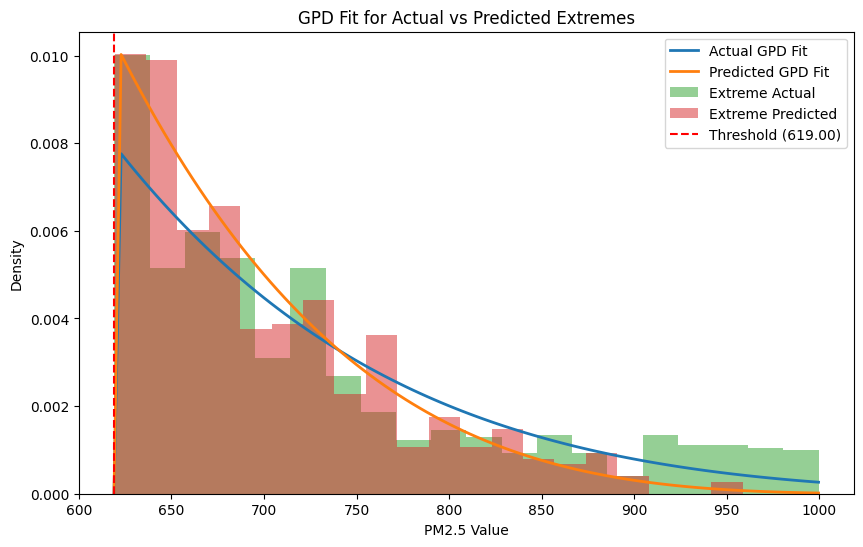

KS Statistic: 0.1260, p-value: 0.0000


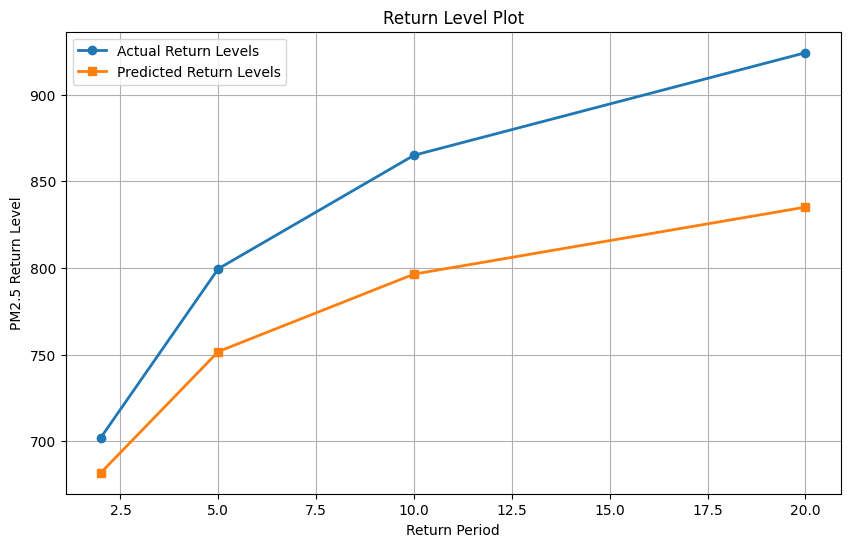

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import genpareto, kstest

# Load your actual and predicted data
data = pd.read_csv('D:/Manoj_Honors/Final/actual_vs_predicted_PM2.5.csv')  # Replace with your path
actual = data['PM2.5_Actual'].values
predicted = data['PM2.5_Predicted'].values

# Define a threshold for extreme values (95th percentile)
threshold = np.percentile(actual, 99.90)  # Adjust percentile if needed
extreme_actual = actual[actual > threshold]
extreme_predicted = predicted[predicted > threshold]

# Function to fit GPD
def fit_gpd(data, threshold):
    exceedances = data - threshold
    params = genpareto.fit(exceedances)
    return params

# Fit GPD to actual and predicted extremes
gpd_params_actual = fit_gpd(extreme_actual, threshold)
gpd_params_predicted = fit_gpd(extreme_predicted, threshold)

# Generate GPD PDF for comparison
x_vals = np.linspace(0, max(extreme_actual.max(), extreme_predicted.max()) - threshold, 100)
gpd_pdf_actual = genpareto.pdf(x_vals, *gpd_params_actual)
gpd_pdf_predicted = genpareto.pdf(x_vals, *gpd_params_predicted)

# Plot GPD fits
plt.figure(figsize=(10, 6))
plt.plot(x_vals + threshold, gpd_pdf_actual, label="Actual GPD Fit", lw=2)
plt.plot(x_vals + threshold, gpd_pdf_predicted, label="Predicted GPD Fit", lw=2)
plt.hist(extreme_actual, bins=20, density=True, alpha=0.5, label="Extreme Actual")
plt.hist(extreme_predicted, bins=20, density=True, alpha=0.5, label="Extreme Predicted")
plt.axvline(threshold, color="red", linestyle="--", label=f"Threshold ({threshold:.2f})")
plt.title("GPD Fit for Actual vs Predicted Extremes")
plt.xlabel("PM2.5 Value")
plt.ylabel("Density")
plt.legend()
plt.show()

# Kolmogorov-Smirnov Test to Compare Extremes
ks_stat, ks_p_value = kstest(extreme_actual, lambda x: genpareto.cdf(x - threshold, *gpd_params_predicted))
print(f"KS Statistic: {ks_stat:.4f}, p-value: {ks_p_value:.4f}")

# Return Level Analysis
return_periods = [2, 5, 10, 20]  # Return periods (years or arbitrary units)
return_levels_actual = threshold + genpareto.ppf(1 - 1/np.array(return_periods), *gpd_params_actual)
return_levels_predicted = threshold + genpareto.ppf(1 - 1/np.array(return_periods), *gpd_params_predicted)

# # Plot Return Levels
# plt.figure(figsize=(10, 6))
# plt.plot(return_periods, return_levels_actual, label="Actual Return Levels", marker="o", lw=2)
# plt.plot(return_periods, return_levels_predicted, label="Predicted Return Levels", marker="s", lw=2)
# plt.title("Return Level Plot")
# plt.xlabel("Return Period")
# plt.ylabel("PM2.5 Return Level")
# plt.legend()
# plt.grid(True)
# plt.show()


In [2]:
import pandas as pd
import numpy as np
import pickle
import os

# Define model paths and corresponding input features
models_info = {
    'STC': {
        'path': r'D:\Manoj_Honors\random_forest_model_PM2.5(STC).pkl',
        'features': ['Time', 'Lat', 'Lon', 'PM2.5_prev_day', 'PM2.5_prev_week', 'Spatial_Avg_PM2.5']
    },
    'CC': {
        'path': r'D:\Manoj_Honors\random_forest_model_PM2.5(CC).pkl',  # Update with actual path to CC model
        'features': ['Time', 'Lat','Lon','NO2_prev_day','NO2_prev_week','Spatial_Avg_NO2','NO2','Ozone','Ozone_prev_day','Ozone_prev_week','Spatial_Avg_Ozone','PM2.5_prev_day','PM2.5_prev_week','Spatial_Avg_PM2.5'
]
    },
    'PCC': {
        'path': r'D:\Manoj_Honors\random_forest_model_PM2.5(PCC).pkl',  # Update with actual path to PCC model
        'features': ['Time', 'Lat','Lon','NO2_prev_day','NO2_prev_week','Spatial_Avg_NO2','NO2','Ozone_prev_day','Ozone_prev_week','Spatial_Avg_Ozone','Ozone']
    }
}

# Load the dataset
dataset_path = r'D:\Manoj_Honors\Merged_Data(Spatio-temporal).csv'  # Replace with your dataset path
data = pd.read_csv(dataset_path)

# Loop through each model, process data, and save results
for model_name, model_info in models_info.items():
    # Load the model
    model_path = model_info['path']
    with open(model_path, 'rb') as file:
        model = pickle.load(file)

    # Get the required features for the model
    input_features = model_info['features']
    required_columns = input_features + ['PM2.5']  # Include 'PM2.5' for actual values
    
    # Drop rows with null values in the required columns
    filtered_data = data.dropna(subset=required_columns)

    # Extract input features and actual values
    X = filtered_data[input_features]
    y_actual = filtered_data['PM2.5']

    # Convert 'Time' to numeric if it's in datetime format
    if 'Time' in X.columns:
        X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9

    # Predict PM2.5 values
    y_predicted = model.predict(X)

    # Create a DataFrame for actual and predicted values
    results = pd.DataFrame({
        'Station_ID': filtered_data['Station_ID'],
        'Time': filtered_data['Time'],
        'Lat': filtered_data['Lat'],
        'Lon': filtered_data['Lon'],
        'PM2.5_Actual': y_actual,
        'PM2.5_Predicted': y_predicted
    })

    # Save the results to a CSV file
    output_path = f'D:/Manoj_Honors/Final/{model_name}_actual_vs_predicted_PM2.5.csv'
    results.to_csv(output_path, index=False)

    print(f"Results for {model_name} saved to '{output_path}'")


C:\Users\Faculty\AppData\Local\Temp\ipykernel_8284\1125259108.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9


Results for STC saved to 'D:/Manoj_Honors/Final/STC_actual_vs_predicted_PM2.5.csv'


C:\Users\Faculty\AppData\Local\Temp\ipykernel_8284\1125259108.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9


Results for CC saved to 'D:/Manoj_Honors/Final/CC_actual_vs_predicted_PM2.5.csv'


C:\Users\Faculty\AppData\Local\Temp\ipykernel_8284\1125259108.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9


Results for PCC saved to 'D:/Manoj_Honors/Final/PCC_actual_vs_predicted_PM2.5.csv'


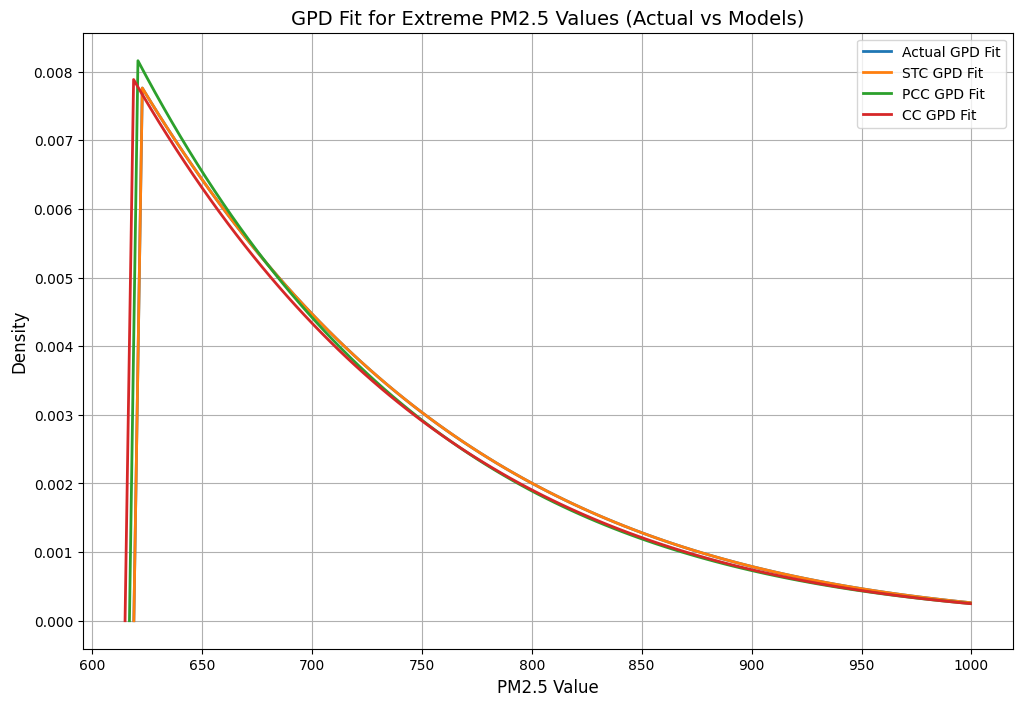

Actual GPD Parameters: Shape=-0.1463, Loc=0.2300, Scale=125.7215
Actual Threshold: 619.0000
STC GPD Parameters: Shape=-0.1463, Loc=0.2300, Scale=125.7215
STC Threshold: 619.0000
PCC GPD Parameters: Shape=-0.1115, Loc=0.5000, Scale=119.5354
PCC Threshold: 617.0000
CC GPD Parameters: Shape=-0.1334, Loc=0.1900, Scale=123.5805
CC Threshold: 615.0000


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import genpareto

# Define file paths for actual, STC, PCC, and CC results
file_paths = {
    "Actual": r"D:/Manoj_Honors/Final/actual_vs_predicted_PM2.5.csv",
    "STC": r"D:/Manoj_Honors/Final/STC_actual_vs_predicted_PM2.5.csv",
    "PCC": r"D:/Manoj_Honors/Final/PCC_actual_vs_predicted_PM2.5.csv",
    "CC": r"D:/Manoj_Honors/Final/CC_actual_vs_predicted_PM2.5.csv"
}

# Function to fit GPD
def fit_gpd(data, threshold):
    exceedances = data - threshold
    params = genpareto.fit(exceedances)
    return params

# Function to process and fit GPD for each dataset
def process_and_fit_gpd(file_path, label, threshold_percentile=99.90):
    # Load the data
    try:
        data = pd.read_csv(file_path)
        if 'PM2.5_Actual' not in data.columns:
            raise KeyError(f"'PM2.5_Actual' column not found in {label} dataset.")
    except Exception as e:
        print(f"Error loading file for {label}: {e}")
        return None, None

    # Extract actual values
    actual = data['PM2.5_Actual'].values
    if len(actual) == 0:
        print(f"No data found in {label} dataset.")
        return None, None

    # Calculate threshold
    threshold = np.percentile(actual, threshold_percentile)
    extreme_actual = actual[actual > threshold]

    # Ensure there are extreme values to fit
    if len(extreme_actual) == 0:
        print(f"No extreme values found in {label} dataset above threshold {threshold}.")
        return None, threshold

    # Fit GPD to extreme values
    gpd_params_actual = fit_gpd(extreme_actual, threshold)

    # Generate GPD PDF
    x_vals = np.linspace(0, extreme_actual.max() - threshold, 100)
    gpd_pdf_actual = genpareto.pdf(x_vals, *gpd_params_actual)

    # Plot GPD fit
    plt.plot(
        x_vals + threshold, 
        gpd_pdf_actual, 
        label=f"{label} GPD Fit", 
        lw=2
    )
    return gpd_params_actual, threshold

# Plot GPD fits for all datasets
plt.figure(figsize=(12, 8))
results = {}

for label, path in file_paths.items():
    gpd_params, threshold = process_and_fit_gpd(path, label)
    if gpd_params is not None:
        results[label] = {"params": gpd_params, "threshold": threshold}

# Customize and display the plot
plt.title("GPD Fit for Extreme PM2.5 Values (Actual vs Models)", fontsize=14)
plt.xlabel("PM2.5 Value", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

# Print GPD parameters for each dataset
for label, result in results.items():
    print(f"{label} GPD Parameters: Shape={result['params'][0]:.4f}, Loc={result['params'][1]:.4f}, Scale={result['params'][2]:.4f}")
    print(f"{label} Threshold: {result['threshold']:.4f}")



In [3]:
import pandas as pd
dataset_path = r'D:\Manoj_Honors\Merged_Data(Spatio-temporal).csv'
df = pd.read_csv(dataset_path)

<>:5: SyntaxWarning: invalid escape sequence '\M'
<>:5: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Faculty\AppData\Local\Temp\ipykernel_23076\1033785322.py:5: SyntaxWarning: invalid escape sequence '\M'
  file_path = "D:\Manoj_Honors\Merged_Data(Spatio-temporal).csv"  # Replace with your CSV file path
C:\Users\Faculty\AppData\Local\Temp\ipykernel_23076\1033785322.py:5: SyntaxWarning: invalid escape sequence '\M'
  file_path = "D:\Manoj_Honors\Merged_Data(Spatio-temporal).csv"  # Replace with your CSV file path


AttributeError: module 'matplotlib' has no attribute 'show'

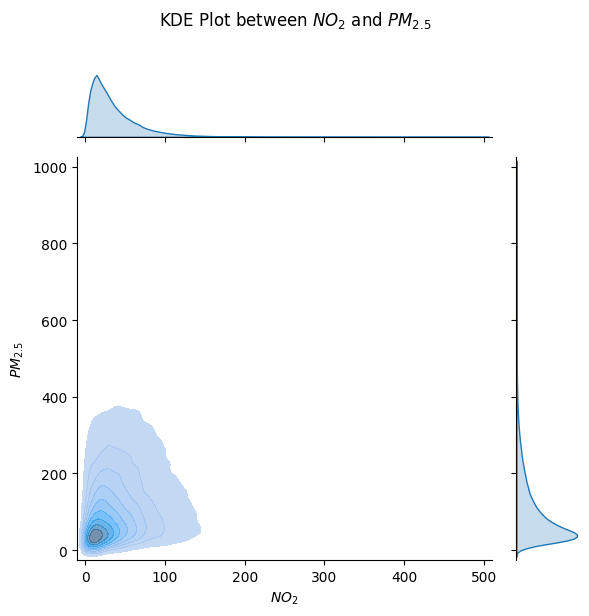

In [2]:
import seaborn as sns
import pandas as pd
import matplotlib as plt
# Assuming `data` is your DataFrame loaded from the CSV file
file_path = "D:\Manoj_Honors\Merged_Data(Spatio-temporal).csv"  # Replace with your CSV file path
data = pd.read_csv(file_path)

# Create the KDE plot
kde_fig = sns.jointplot(
    data=data, 
    x="NO2", 
    y="PM2.5", 
    kind='kde', 
    fill=True, 
    hue=None,  # Add hue if you have a categorical variable for color separation
    joint_kws={'alpha': 0.7}
)

# Customize labels
kde_fig.ax_joint.set_xlabel('$NO_2$')
kde_fig.ax_joint.set_ylabel('$PM_{2.5}$')

# Show the plot
kde_fig.fig.suptitle('KDE Plot between $NO_2$ and $PM_{2.5}$', y=1.02)  # Adjust title position
kde_fig.fig.tight_layout()
plt.show()

